# Segementing Data with k-Means Clustering

## Learning Objectives

The primary objective of clustering is to group items within a dataset based on similarity. `k-Means Clustering` is one of the most popular and easy to use clustering appraoches. With `k-Means clustering`, similarity is based on a distance metric known as euclidean distance. By the end of the tutorial, you will have learnt:

- How to import, explore and prepare data for k-Means Clustering
- How to segment data using k-Means Clustering
- How to evaluate and visualize clusters
- How to choose an appropriate number of clusters
- How to analyze the results of k-Means Clustering

## 1. Collect the Data

Let's import and preview it:

In [2]:
import pandas as pd
customers = pd.read_csv('mallcustomers.csv')

In [3]:
customers.head()

,CustomerID,Gender,Age,Income,SpendingScore
0,1,Male,19,15000,39
1,2,Male,21,15000,81
2,3,Female,20,16000,6
3,4,Female,23,16000,77
4,5,Female,31,17000,40


## 2. Explore the Data

Next, let's get a concise summary of the structure and the values within the dataset:

In [4]:
customers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   CustomerID     200 non-null    int64 
 1   Gender         200 non-null    object
 2   Age            200 non-null    int64 
 3   Income         200 non-null    int64 
 4   SpendingScore  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [5]:
customers.describe(include='all').round(2)

,CustomerID,Gender,Age,Income,SpendingScore
count,200.00,200,200.00,200.00,200.00
unique,NaN,2,NaN,NaN,NaN
top,NaN,Female,NaN,NaN,NaN
freq,NaN,112,NaN,NaN,NaN
mean,100.50,NaN,38.85,60560.00,50.20
std,57.88,NaN,13.97,26264.72,25.82
min,1.00,NaN,18.00,15000.00,1.00
25%,50.75,NaN,28.75,41500.00,34.75
50%,100.50,NaN,36.00,61500.00,50.00
75%,150.25,NaN,49.00,78000.00,73.00


A visual exploration of the dataset can provide us with some additional insight.

In [20]:
from matplotlib import pyplot as plt
import seaborn as sns
sns.set_theme()

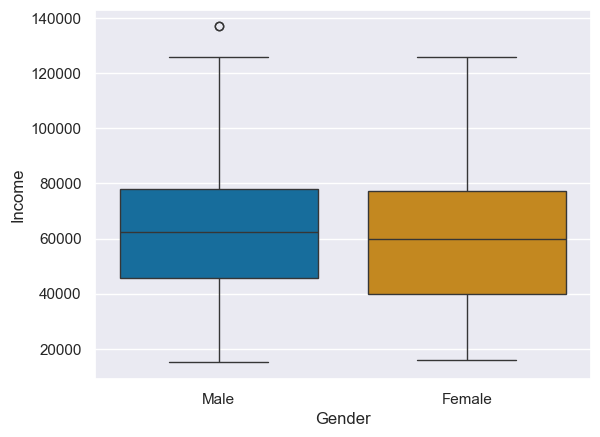

In [23]:
ax = sns.boxplot(data=customers,
                 x='Gender',
                 y='Income',
                 hue='Gender',
                 palette='colorblind',
                 dodge=False)

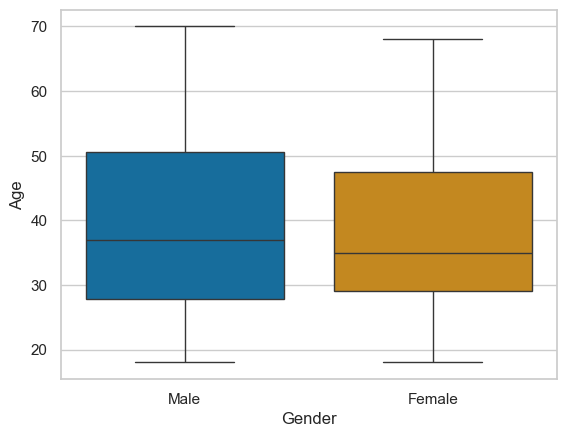

In [19]:
ax = sns.boxplot(data=customers,
                 x='Gender',
                 y='Age',
                 hue='Gender',
                 palette='colorblind',
                 dodge=False)

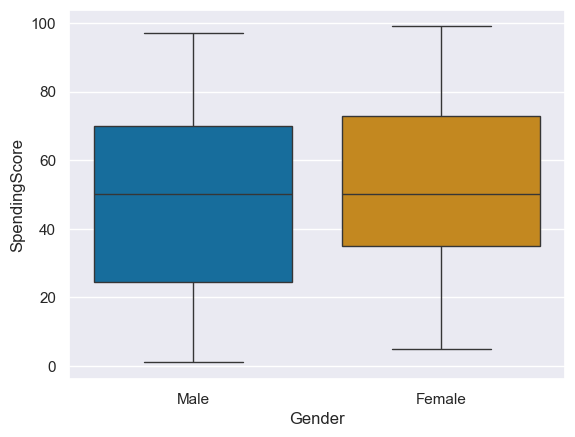

In [22]:
ax = sns.boxplot(data=customers,
                 x = 'Gender',
                 y = 'SpendingScore',
                 hue = 'Gender',
                 palette = 'colorblind',
                 dodge = False
)

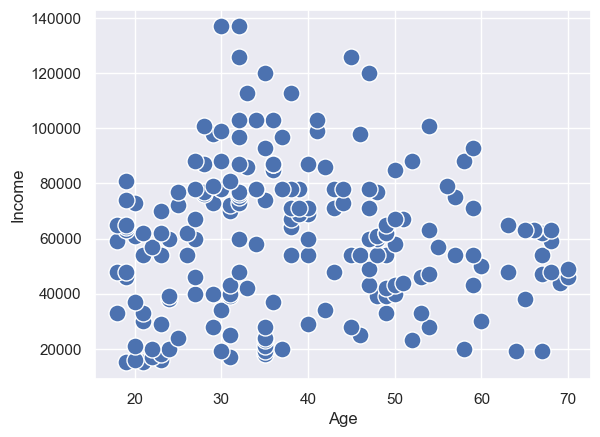

In [30]:
ax = sns.scatterplot(
    data=customers,
    x='Age',
    y='Income',
    s = 150,)

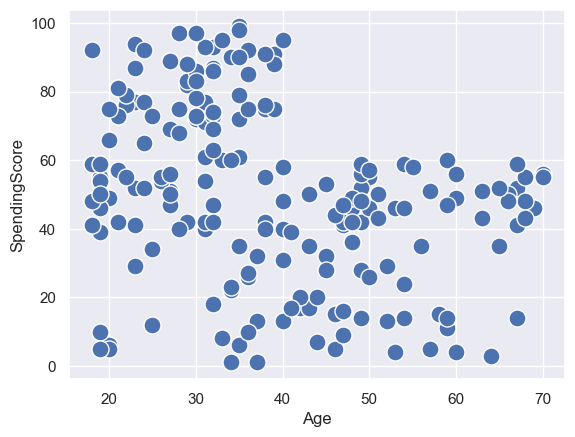

In [32]:
ax = sns.scatterplot(
    data=customers,
    x='Age',
    y='SpendingScore',
    s = 150)

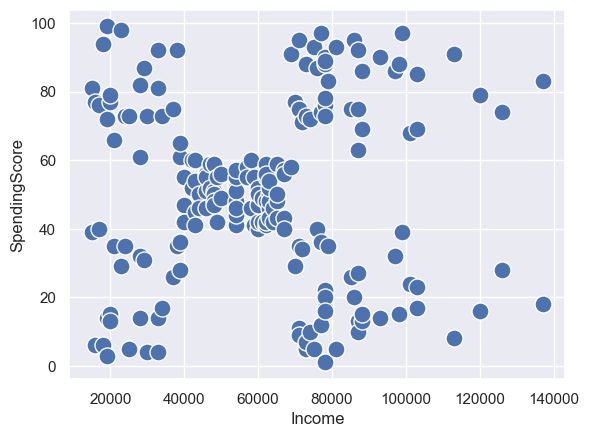

In [33]:
ax = sns.scatterplot(
    data=customers,
    x='Income',
    y='SpendingScore',
    s = 150,)

## 3. Preparing the Data

In [34]:
customers[['Income', 'SpendingScore']].describe().round(2)

,Income,SpendingScore
count,200.00,200.00
mean,60560.00,50.20
std,26264.72,25.82
min,15000.00,1.00
25%,41500.00,34.75
50%,61500.00,50.00
75%,78000.00,73.00
max,137000.00,99.00


In [36]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

In [43]:
customers_scaled = scaler.fit_transform(customers[['Income', 'SpendingScore']])
customers_scaled

array([[-1.73899919, -0.43480148],
       [-1.73899919,  1.19570407],
       [-1.70082976, -1.71591298],
       [-1.70082976,  1.04041783],
       [-1.66266033, -0.39597992],
       [-1.66266033,  1.00159627],
       [-1.62449091, -1.71591298],
       [-1.62449091,  1.70038436],
       [-1.58632148, -1.83237767],
       [-1.58632148,  0.84631002],
       [-1.58632148, -1.4053405 ],
       [-1.58632148,  1.89449216],
       [-1.54815205, -1.36651894],
       [-1.54815205,  1.04041783],
       [-1.54815205, -1.44416206],
       [-1.54815205,  1.11806095],
       [-1.50998262, -0.59008772],
       [-1.50998262,  0.61338066],
       [-1.43364376, -0.82301709],
       [-1.43364376,  1.8556706 ],
       [-1.39547433, -0.59008772],
       [-1.39547433,  0.88513158],
       [-1.3573049 , -1.75473454],
       [-1.3573049 ,  0.88513158],
       [-1.24279661, -1.4053405 ],
       [-1.24279661,  1.23452563],
       [-1.24279661, -0.7065524 ],
       [-1.24279661,  0.41927286],
       [-1.20462718,

In [42]:
customers_scaled = pd.DataFrame(customers_scaled, columns=['Income', 'SpendingScore'])
customers_scaled.head()

,Income,SpendingScore
0,-1.738999,-0.434801
1,-1.738999,1.195704
2,-1.700830,-1.715913
3,-1.700830,1.040418
4,-1.662660,-0.395980


In [45]:
# Ensure customers_scaled is a DataFrame before calling describe()
# If it's a numpy array (from scaler.fit_transform) convert it to a DataFrame first.
customers_scaled = customers_scaled if hasattr(customers_scaled, "describe") else pd.DataFrame(customers_scaled, columns=['Income', 'SpendingScore'])
customers_scaled.describe().round(2)

,Income,SpendingScore
count,200.00,200.00
mean,-0.00,-0.00
std,1.00,1.00
min,-1.74,-1.91
25%,-0.73,-0.60
50%,0.04,-0.01
75%,0.67,0.89
max,2.92,1.89


## 3. Create the Clusters

In [46]:
from sklearn.cluster import KMeans
km = KMeans(n_clusters=3, n_init=25, random_state=1234)

In [47]:
km.fit(customers_scaled)

,n_clusters,3
,init,'k-means++'
,n_init,25
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,1234
,copy_x,True
,algorithm,'lloyd'


In [48]:
km.labels_

array([2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 1, 0, 1, 0, 1, 0, 1, 0, 1,
       0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1,
       0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1,
       0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1,
       0, 1], dtype=int32)

In [50]:
km.inertia_

157.70400815035947

## 4. Evaluate and Visaualize the Clusters

In [51]:
pd.Series(km.labels_).value_counts().sort_index()

0     38
1     39
2    123
Name: count, dtype: int64

In [52]:
km.cluster_centers_

array([[ 1.00919971, -1.22553537],
       [ 0.99158305,  1.23950275],
       [-0.62618966, -0.01439238]])

In [53]:
cluster_centers = pd.DataFrame(km.cluster_centers_, columns=['Income', 'SpendingScore'])
cluster_centers

,Income,SpendingScore
0,1.009200,-1.225535
1,0.991583,1.239503
2,-0.626190,-0.014392


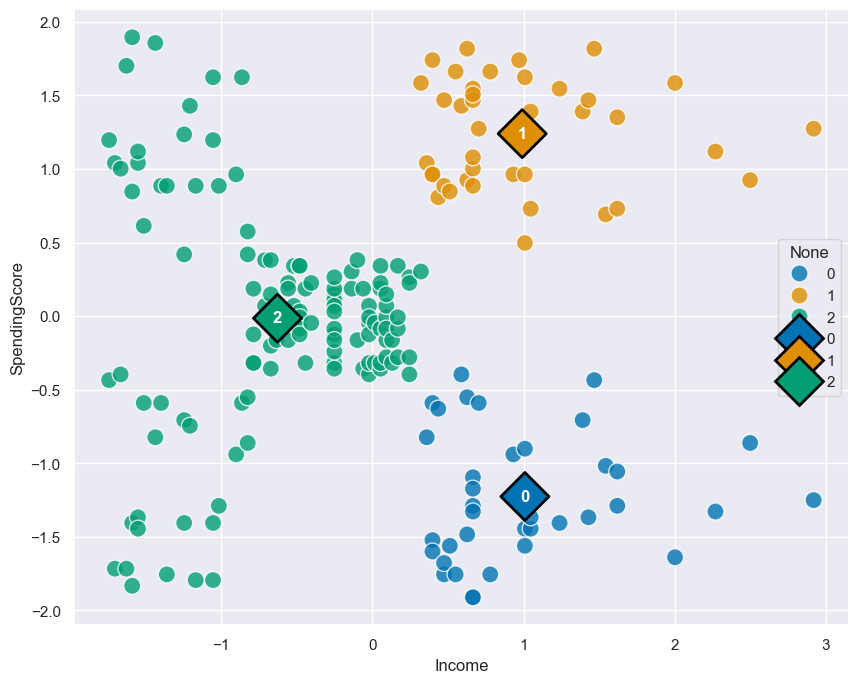

In [62]:
# Set the figure size
plt.figure(figsize=(10, 8))

# Plot the clustered data points
ax = sns.scatterplot(
    data=customers_scaled,
    x='Income',
    y='SpendingScore',
    hue=km.labels_,
    palette='colorblind',
    alpha=0.8,
    s=150,
    legend='full')

# Plot the centroids
ax = sns.scatterplot(
    data=cluster_centers,
    x='Income',
    y='SpendingScore',
    hue = cluster_centers.index,
    palette='colorblind',
    s=600,
    marker='D',
    ec='black',
    legend='full')

# Add Centroid labels
for i in range(len(cluster_centers)):
    plt.text(
        x=cluster_centers.Income[i],
        y=cluster_centers.SpendingScore[i],
        s=i,
        horizontalalignment='center',
        verticalalignment='center',
        color='white',
        fontsize=12,
        weight='bold'
        )

## 5. Choose the right number of Clusters

**The Within CLuster Sum of Square (WCSS)**

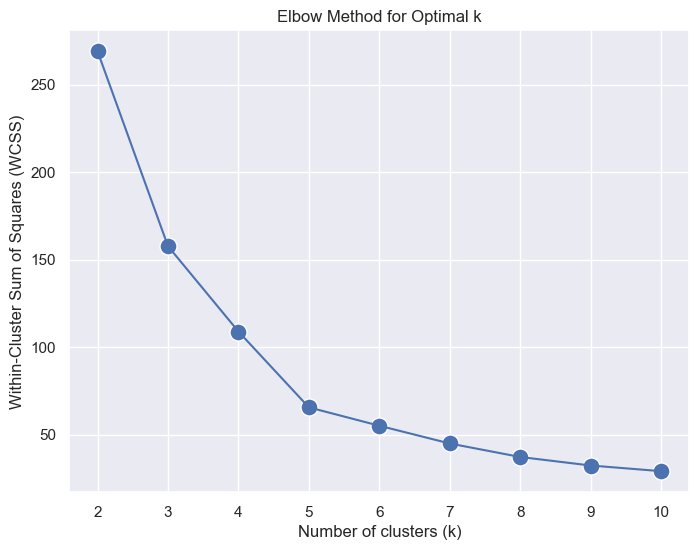

In [69]:
wcss = []
for k in range(2, 11):
    km = KMeans(n_clusters=k, n_init=25, random_state=1234)
    km.fit(customers_scaled)
    wcss.append(km.inertia_)

wcss_series = pd.Series(wcss, index=range(2, 11))

plt.figure(figsize=(8, 6))
ax = sns.lineplot(y=wcss_series,
                  x=wcss_series.index)
ax = sns.scatterplot(y=wcss_series,
                     x=wcss_series.index,
                     s=150)
ax = ax.set(xlabel='Number of clusters (k)',
            ylabel='Within-Cluster Sum of Squares (WCSS)',
            title='Elbow Method for Optimal k')

**The Average Silhouette Score**

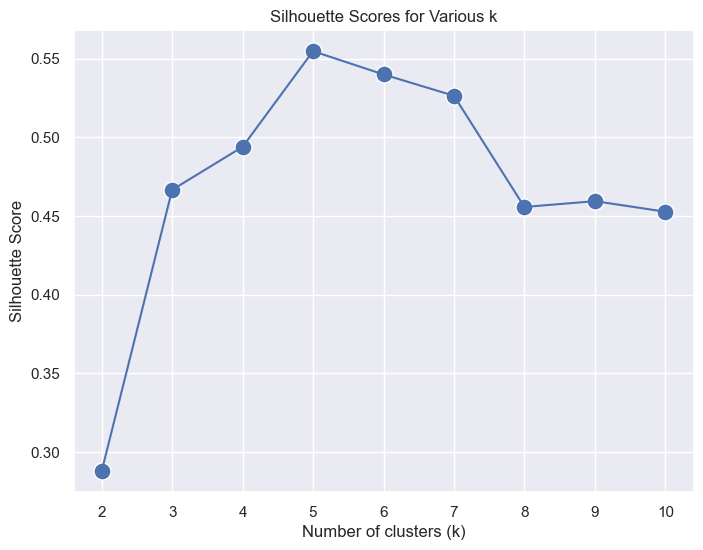

In [70]:
from sklearn.metrics import silhouette_score
silhouette_scores = []
for k in range(2, 11):
    km = KMeans(n_clusters=k, n_init=25, random_state=1234)
    km.fit(customers_scaled)
    score = silhouette_score(customers_scaled, km.labels_)
    silhouette_scores.append(score)

silhoutte_series = pd.Series(silhouette_scores, index=range(2, 11))

plt.figure(figsize=(8, 6))
ax = sns.lineplot(y=silhoutte_series,
                  x=silhoutte_series.index)
ax = sns.scatterplot(y=silhoutte_series,
                     x=silhoutte_series.index,
                     s=150)
ax = ax.set(xlabel='Number of clusters (k)',
            ylabel='Silhouette Score',
            title='Silhouette Scores for Various k')

**The Calinkski Harabasz Score**

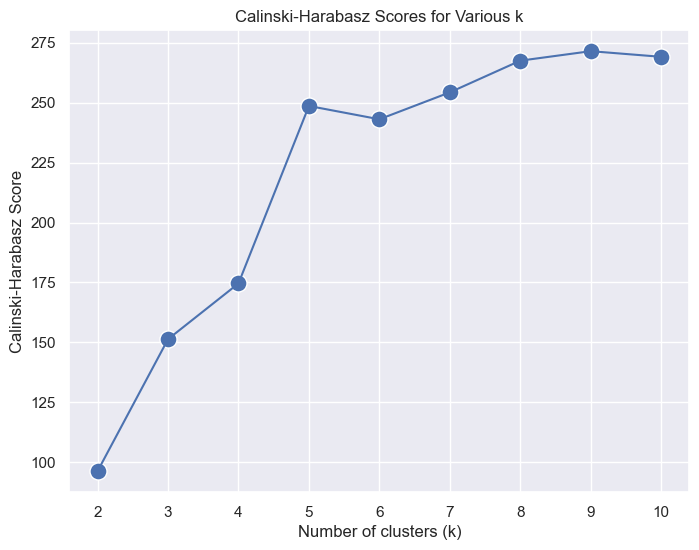

In [71]:
from sklearn.metrics import calinski_harabasz_score

calinski_harabasz_scores = []
for k in range(2, 11):
    km = KMeans(n_clusters=k, n_init=25, random_state=1234)
    km.fit(customers_scaled)
    score = calinski_harabasz_score(customers_scaled, km.labels_)
    calinski_harabasz_scores.append(score)

calinski_series = pd.Series(calinski_harabasz_scores, index=range(2, 11))

plt.figure(figsize=(8, 6))
ax = sns.lineplot(y=calinski_series,
                  x=calinski_series.index)
ax = sns.scatterplot(y=calinski_series,
                     x=calinski_series.index,
                     s=150)
ax = ax.set(xlabel='Number of clusters (k)',
            ylabel='Calinski-Harabasz Score',
            title='Calinski-Harabasz Scores for Various k')

## 6. Analyze and Interprete the Clusters

In [72]:
km = KMeans(n_clusters=5, n_init=25, random_state=1234)
km.fit(customers_scaled)

,n_clusters,5
,init,'k-means++'
,n_init,25
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,1234
,copy_x,True
,algorithm,'lloyd'


In [73]:
cluster_centers = pd.DataFrame(km.cluster_centers_, columns=['Income', 'SpendingScore'])
cluster_centers

,Income,SpendingScore
0,-1.307519,-1.136965
1,0.991583,1.239503
2,-1.329545,1.132178
3,1.055003,-1.284439
4,-0.200913,-0.026456


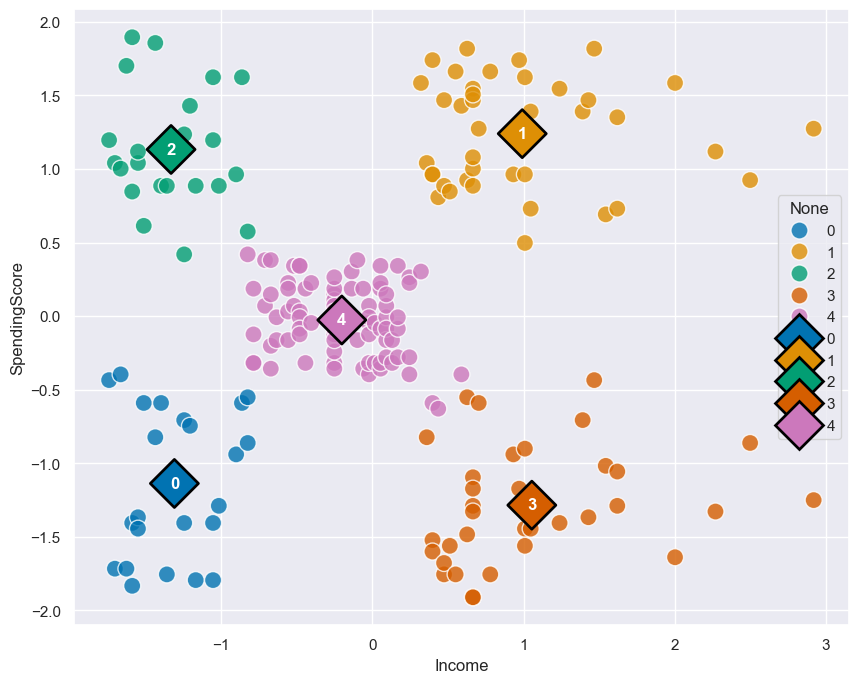

In [74]:
# Set the figure size
plt.figure(figsize=(10, 8))

# Plot the clustered data points
ax = sns.scatterplot(
    data=customers_scaled,
    x='Income',
    y='SpendingScore',
    hue=km.labels_,
    palette='colorblind',
    alpha=0.8,
    s=150,
    legend='full')

# Plot the centroids
ax = sns.scatterplot(
    data=cluster_centers,
    x='Income',
    y='SpendingScore',
    hue = cluster_centers.index,
    palette='colorblind',
    s=600,
    marker='D',
    ec='black',
    legend='full')

# Add Centroid labels
for i in range(len(cluster_centers)):
    plt.text(
        x=cluster_centers.Income[i],
        y=cluster_centers.SpendingScore[i],
        s=i,
        horizontalalignment='center',
        verticalalignment='center',
        color='white',
        fontsize=12,
        weight='bold'
        )

In [75]:
customers['Cluster'] = km.labels_.tolist()
customers.head(10)

,CustomerID,Gender,Age,Income,SpendingScore,Cluster
0,1,Male,19,15000,39,0
1,2,Male,21,15000,81,2
2,3,Female,20,16000,6,0
3,4,Female,23,16000,77,2
4,5,Female,31,17000,40,0
5,6,Female,22,17000,76,2
6,7,Female,35,18000,6,0
7,8,Female,23,18000,94,2
8,9,Male,64,19000,3,0
9,10,Female,30,19000,72,2


In [76]:
customers = pd.get_dummies(customers, columns=['Gender'])
customers.head(10)

,CustomerID,Age,Income,SpendingScore,Cluster,Gender_Female,Gender_Male
0,1,19,15000,39,0,False,True
1,2,21,15000,81,2,False,True
2,3,20,16000,6,0,True,False
3,4,23,16000,77,2,True,False
4,5,31,17000,40,0,True,False
5,6,22,17000,76,2,True,False
6,7,35,18000,6,0,True,False
7,8,23,18000,94,2,True,False
8,9,64,19000,3,0,False,True
9,10,30,19000,72,2,True,False


In [78]:
customers.agg(
    {
        'Gender_Female': 'mean',
        'Gender_Male': 'mean',
        'Age': 'median',
        'Income': 'median',
        'SpendingScore': 'median'
    }
).round(2)

Gender_Female        0.56
Gender_Male          0.44
Age                 36.00
Income           61500.00
SpendingScore       50.00
dtype: float64

In [79]:
customers.groupby('Cluster').agg(
    {
        'Gender_Female': 'mean',
        'Gender_Male': 'mean',
        'Age': 'median',
        'Income': 'median',
        'SpendingScore': 'median'
    }
).round(2)

,Gender_Female,Gender_Male,Age,Income,SpendingScore
Cluster,,,,,
0,0.61,0.39,46.0,25000.0,17.0
1,0.54,0.46,32.0,79000.0,83.0
2,0.59,0.41,23.5,24500.0,77.0
3,0.46,0.54,42.0,85000.0,16.0
4,0.59,0.41,46.0,54000.0,50.0
